# 1/4 drone MPC

This script runs an optimal MPC (using casadi) for the 1/4 drone case study, using a NARX model identified.

In [2]:
# 1. Imports and Definitions
import numpy as np
import matplotlib.pyplot as plt
import time
from tqdm.auto import tqdm
from casadi import SX, MX, DM, Function, nlpsol, vertcat
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

Ts = 0.05  # Sampling time in seconds
ny_model = 5
nu_model = 5
nx = ny_model + nu_model


C:\Users\mathe\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# 2. CasADi Formulation of Hard-coded NARX Model
x = SX.sym('x', nx)
y_syms = [x[i] for i in range(ny_model)]
u_syms = [x[ny_model + i] for i in range(nu_model)]
u_sym = SX.sym('u')

# Hard-coded NARX equation identified via FROLS
y_k = (
    + 1.9373 * (y_syms[0])
    - 0.9545 * (y_syms[1])
    + 0.0007 * (u_syms[1] * u_syms[1])
    + 0.0000 * (u_syms[3] * u_syms[4] * u_syms[4])
    - 0.0004 * (u_syms[1] * u_syms[2])
)

y_next = vertcat(y_k, x[0:ny_model-1])
u_next = vertcat(u_sym, x[ny_model:ny_model+nu_model-1])
x_next = vertcat(y_next, u_next)

F = Function('F', [x, u_sym], [x_next, y_k], ['x0', 'p'], ['xf', 'yk'])


In [4]:
# 3. MPC Setup
N = 10
data = {
    'Ts': Ts,
    'x0': np.zeros(nx),
    'u_min': np.array([0.0]),
    'u_max': np.array([100.0]),
    'u_guess': np.array([0.0]),
    'x_guess': np.zeros(nx),
    'tol': 1e-8,
}

def vcat(lst):
    return vertcat(*[DM(x) if not hasattr(x, 'is_symbolic') else x for x in lst])

w, lbw, ubw, w0 = [], [], [], []
g, lbg, ubg = [], [], []
J = 0

xk_param = MX.sym('xk_param', nx)
Pref = MX.sym('Pref', N)

xk = MX.sym('x0', nx)
w.append(xk)
lbw.append(np.full(nx, -np.inf))
ubw.append(np.full(nx, np.inf))
w0.append(data['x_guess'])

g.append(xk - xk_param)
lbg.append(np.zeros(nx))
ubg.append(np.zeros(nx))

for k in range(N):
    uk = MX.sym(f'u_{k}', 1)
    w.append(uk)
    lbw.append(data['u_min'])
    ubw.append(data['u_max'])
    w0.append(data['u_guess'])
    
    Fk = F(x0=xk, p=uk)
    xnext = Fk['xf']
    yk = Fk['yk']
    
    if k == 0:
        du = uk - xk[ny_model]
    else:
        du = uk - u_prev
    u_prev = uk
    
    J = J + 1e3 * (yk - Pref[k])**2 + 0.1 * uk**2 + 50.0 * du**2
    
    xk = MX.sym(f'x_{k+1}', nx)
    w.append(xk)
    lbw.append(np.full(nx, -np.inf))
    ubw.append(np.full(nx, np.inf))
    w0.append(data['x_guess'])
    
    g.append(xk - xnext)
    lbg.append(np.zeros(nx))
    ubg.append(np.zeros(nx))

w = vertcat(*w)
lbw = vcat(lbw)
ubw = vcat(ubw)
w0 = vcat(w0)
g = vertcat(*g)
lbg = vcat(lbg)
ubg = vcat(ubg)

nlp = {'x': w, 'g': g, 'f': J, 'p': vertcat(xk_param, Pref)}
solver = nlpsol('solver', 'ipopt', nlp, {'ipopt.print_level': 0, 'print_time': 0})


In [5]:
# 4. Reference Sequence Generation
# Sequence of 5s each, from 0 to 90 with step of 10
step_duration = 5.0
samples_per_step = int(round(step_duration / Ts))
step_levels = np.arange(0, 100, 10)  # 0, 10, ..., 90

t_total = len(step_levels) * step_duration
steps = len(step_levels) * samples_per_step

tvec = np.arange(0, t_total, Ts)
x2ref = np.zeros(steps)

for i, level in enumerate(step_levels):
    x2ref[i*samples_per_step : (i+1)*samples_per_step] = level

# Padding for MPC horizon
x2ref_full = np.concatenate([x2ref, np.full(N, 90.0)])


In [6]:
# 5. Simulation Loop
xsim = np.zeros((nx, 1))
ysim = []
usim = []
tvec_sim = []
dtvec = []

w0_val = np.zeros(w.shape[0])

for k in tqdm(range(steps), desc="MPC Simulation"):
    t = k * Ts
    ref_window = x2ref_full[k : k + N]
    
    pval = np.concatenate([xsim[:, -1], ref_window])
    
    tic = time.perf_counter()
    sol = solver(x0=w0_val, lbx=lbw, ubx=ubw, lbg=lbg, ubg=ubg, p=pval)
    dtvec.append(time.perf_counter() - tic)
    
    w_opt = sol['x'].full().flatten()
    u_opt = w_opt[nx] # The first u after the initial x0
    
    # Open Loop Simulation using NARX model F
    sim_step = F(x0=xsim[:, -1], p=u_opt)
    xk1 = sim_step['xf'].full().flatten()
    yk = sim_step['yk'].full().item()
    
    xsim = np.c_[xsim, xk1]
    usim.append(u_opt)
    ysim.append(yk)
    tvec_sim.append(t)
    
    # Warm start
    w0_val = w_opt


MPC Simulation:   0%|          | 0/1000 [00:00<?, ?it/s]

MPC Simulation:   1%|          | 8/1000 [00:00<00:13, 73.91it/s]


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



MPC Simulation: 100%|██████████| 1000/1000 [00:06<00:00, 162.31it/s]


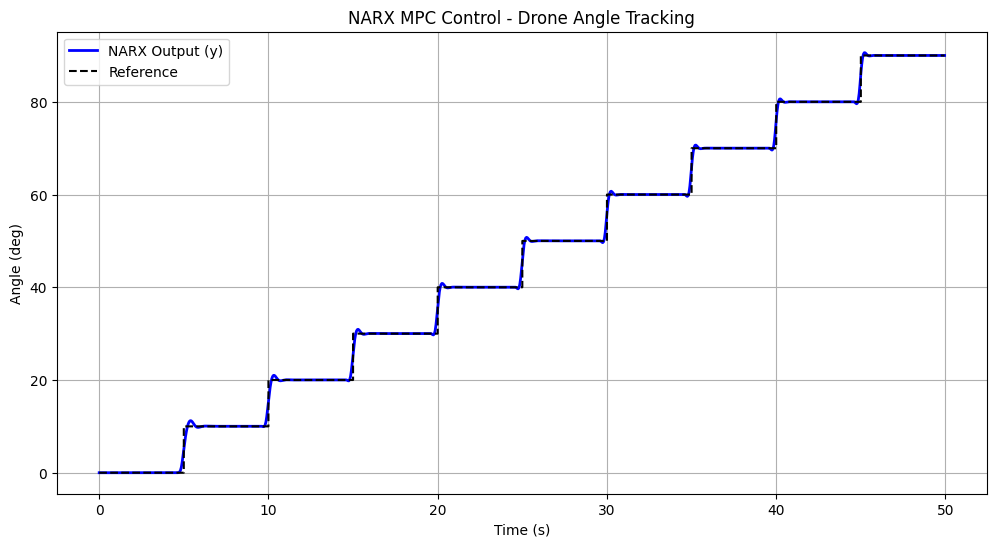

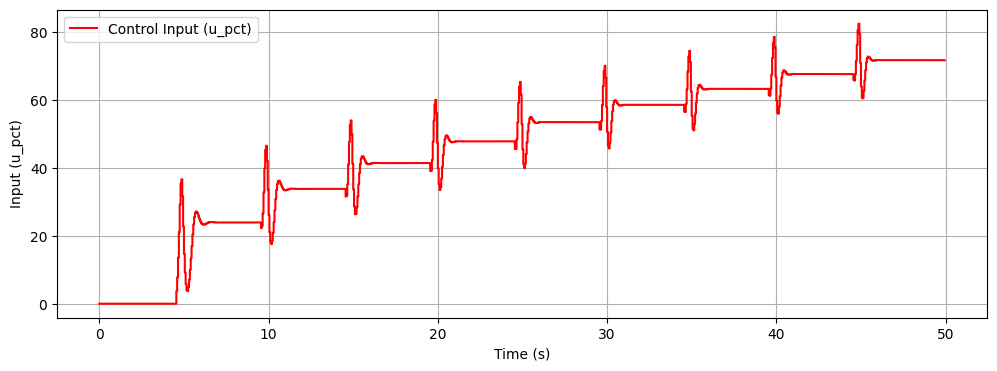

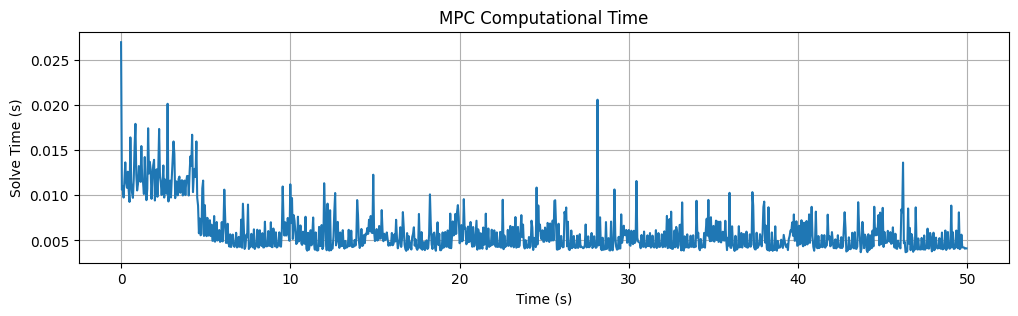

In [7]:
# 6. Plotting Results
plt.figure(figsize=(12, 6))
plt.plot(tvec_sim, ysim, 'b-', linewidth=2, label='NARX Output (y)')
plt.step(tvec_sim, x2ref[:len(tvec_sim)], where='post', color='k', linestyle='--', label='Reference')
plt.ylabel('Angle (deg)')
plt.xlabel('Time (s)')
plt.title('NARX MPC Control - Drone Angle Tracking')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.step(tvec_sim, usim, where='post', color='r', label='Control Input (u_pct)')
plt.ylabel('Input (u_pct)')
plt.xlabel('Time (s)')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(tvec_sim, dtvec)
plt.grid(True)
plt.xlabel('Time (s)')
plt.ylabel('Solve Time (s)')
plt.title('MPC Computational Time')
plt.show()


## Dataset Generation
Using a rich combination of sine, step, and chirp signals.

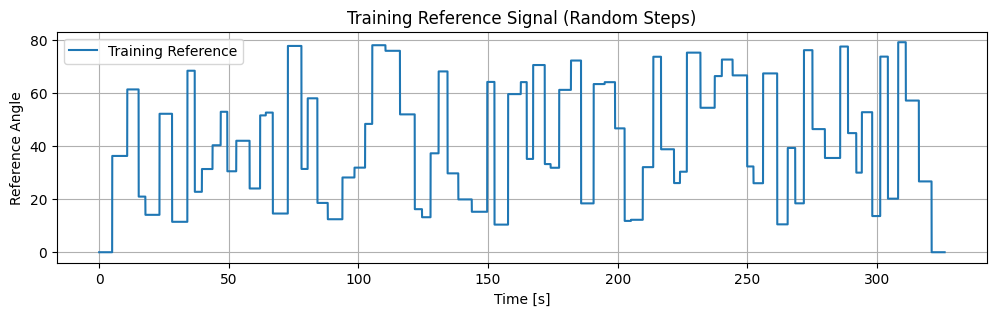

In [8]:
# 7. Training Reference Signal Generation (Rich Signal 0 to 45 deg, 10s changes)
import numpy as np
import matplotlib.pyplot as plt

T_train = 300.0
T_stab = 5.0
tvec_train = np.arange(0.0, T_train + T_stab + N * Ts + Ts, Ts)

np.random.seed(42)
x2ref_train = np.zeros_like(tvec_train)

stab_idx = int(round(T_stab / Ts))
x2ref_train[:stab_idx] = 0.0

t_idx = stab_idx
while t_idx < len(tvec_train):
    duration = 10.0  # Fixado em 10 segundos conforme pedido
    idx_dur = int(round(duration / Ts))
    segment_end = min(t_idx + idx_dur, len(tvec_train))
    
    sig_type = np.random.choice(['step', 'sine', 'chirp'])
    t_seg = tvec_train[t_idx:segment_end]
    
    min_val = np.random.uniform(0.0, 20.0)
    max_val = np.random.uniform(25.0, 45.0)
    offset = (max_val + min_val) / 2.0
    amp = (max_val - min_val) / 2.0
    
    if sig_type == 'step':
        val = np.random.uniform(0.0, 45.0)
        x2ref_train[t_idx:segment_end] = val
    elif sig_type == 'sine':
        freq = np.random.uniform(0.05, 0.2)
        phase = np.random.uniform(0, 2*np.pi)
        x2ref_train[t_idx:segment_end] = offset + amp * np.sin(2 * np.pi * freq * t_seg + phase)
    else: # chirp-like
        freq_start = np.random.uniform(0.05, 0.1)
        freq_end = np.random.uniform(0.1, 0.3)
        instant_freq = np.linspace(freq_start, freq_end, segment_end - t_idx)
        x2ref_train[t_idx:segment_end] = offset + amp * np.sin(2 * np.pi * instant_freq * (t_seg - t_seg[0]))
        
    t_idx = segment_end

steps_train = len(x2ref_train)

plt.figure(figsize=(12, 3))
plt.plot(tvec_train, x2ref_train, label='x2ref_train (Rich Signal [0, 45])')
plt.xlabel('Time [s]')
plt.ylabel('Reference Angle')
plt.title('Training Reference Signal (Changes every 10s)')
plt.legend()
plt.grid(True)
plt.show()


Simulating MPC over Rich Signal for Dataset...


MPC Dataset Collection: 100%|██████████| 6513/6513 [00:46<00:00, 138.91it/s]


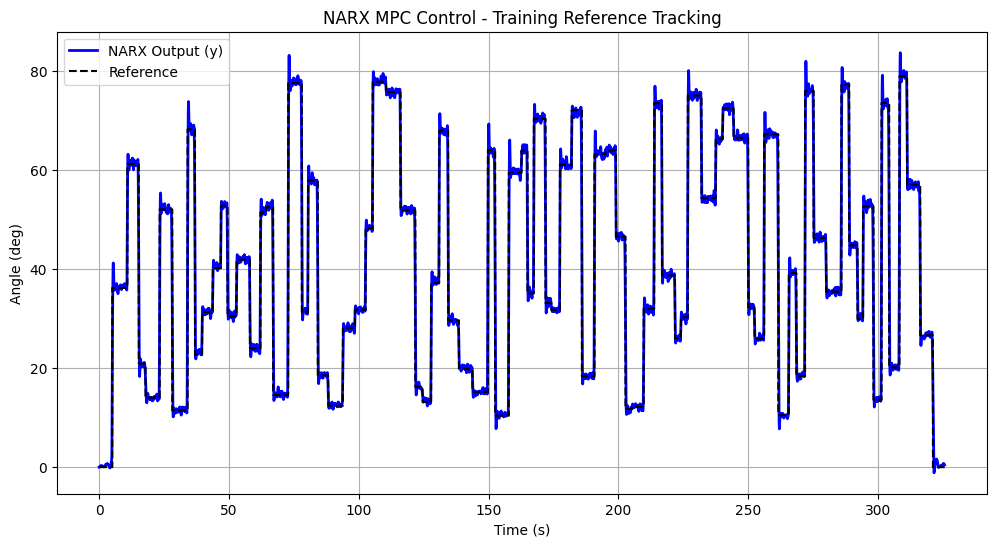

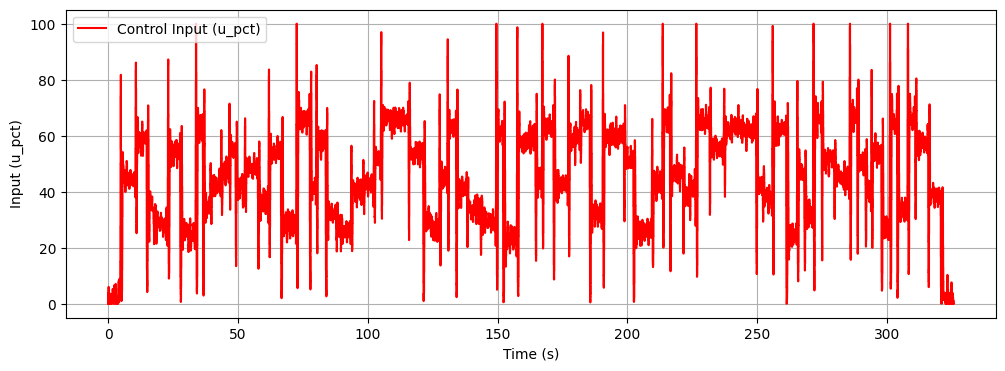

In [9]:
# 8. Simulation Loop (Rich Signal Dataset Collection)
xsim_train = np.zeros((nx, 1))
ysim_train = []
usim_train = []
w0_val = np.zeros(w.shape[0])

print("Simulating MPC over Rich Signal for Dataset...")
sim_steps_train = steps_train - N
for k in tqdm(range(sim_steps_train), desc="MPC Dataset Collection"):
    ref_window = x2ref_train[k : k + N]
    pval = np.concatenate([xsim_train[:, -1], ref_window])
    
    sol = solver(x0=w0_val, lbx=lbw, ubx=ubw, lbg=lbg, ubg=ubg, p=pval)
    
    w_opt = sol['x'].full().flatten()
    u_opt = w_opt[nx]
    
    # Add exploratory noise to the applied control input (NEW)
    u_applied = np.random.normal(u_opt, 3.0)  # NEW: standard deviation of 3.0% control noise
    u_applied = np.clip(u_applied, data['u_min'][0], data['u_max'][0])  # NEW: respect bounds
    
    sim_step = F(x0=xsim_train[:, -1], p=u_applied)  # NEW: apply noisy control to model
    xk1 = sim_step['xf'].full().flatten()
    yk = sim_step['yk'].full().item()
    
    xsim_train = np.c_[xsim_train, xk1]
    usim_train.append(u_opt)  # Target remains the optimal control (NEW)
    ysim_train.append(yk)
    w0_val = w_opt

# Collect Dataset for ANN
# P_data = np.array([np.concatenate([xsim_train[:, k], x2ref_train[k : k + N]]) for k in range(sim_steps_train)])
P_data = np.array([np.concatenate([xsim_train[:, k], x2ref_train[k : k + N]]) for k in range(sim_steps_train)])
U_data = np.array(usim_train).reshape(-1, 1)


# --- Plotting MPC Results ---
tvec_sim_train = tvec_train[:sim_steps_train]
# 1. Output (y) vs Reference
plt.figure(figsize=(12, 6))
plt.plot(tvec_sim_train, ysim_train, 'b-', linewidth=2, label='NARX Output (y)')
plt.step(tvec_sim_train, x2ref_train[:sim_steps_train], where='post', color='k', linestyle='--', label='Reference')
plt.ylabel('Angle (deg)')
plt.xlabel('Time (s)')
plt.title('NARX MPC Control - Training Reference Tracking')
plt.grid(True)
plt.legend()
plt.show()
# 2. Control Input (u)
plt.figure(figsize=(12, 4))
plt.step(tvec_sim_train, usim_train, where='post', color='r', label='Control Input (u_pct)')
plt.ylabel('Input (u_pct)')
plt.xlabel('Time (s)')
plt.grid(True)
plt.legend()
plt.show()


Training ANN...
Epoch 10/150 - Train Loss: 6.2271 - Val Loss: 5.3636
Epoch 20/150 - Train Loss: 3.9581 - Val Loss: 3.2498
Epoch 30/150 - Train Loss: 3.1600 - Val Loss: 2.6674
Epoch 40/150 - Train Loss: 2.5016 - Val Loss: 2.2323
Epoch 50/150 - Train Loss: 2.0034 - Val Loss: 1.7334
Epoch 60/150 - Train Loss: 1.6561 - Val Loss: 1.5906
Epoch 70/150 - Train Loss: 1.4706 - Val Loss: 1.5599
Epoch 80/150 - Train Loss: 1.1481 - Val Loss: 1.1699
Epoch 90/150 - Train Loss: 0.9589 - Val Loss: 1.3258
Epoch 100/150 - Train Loss: 0.6001 - Val Loss: 0.8510
Epoch 110/150 - Train Loss: 0.4985 - Val Loss: 0.5406
Epoch 120/150 - Train Loss: 0.5078 - Val Loss: 0.4262
Epoch 130/150 - Train Loss: 0.3657 - Val Loss: 0.3508
Epoch 140/150 - Train Loss: 0.3381 - Val Loss: 0.6145
Epoch 150/150 - Train Loss: 0.3057 - Val Loss: 0.3623


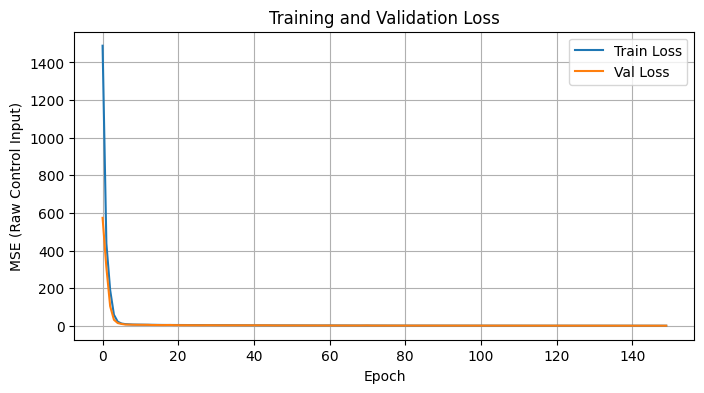

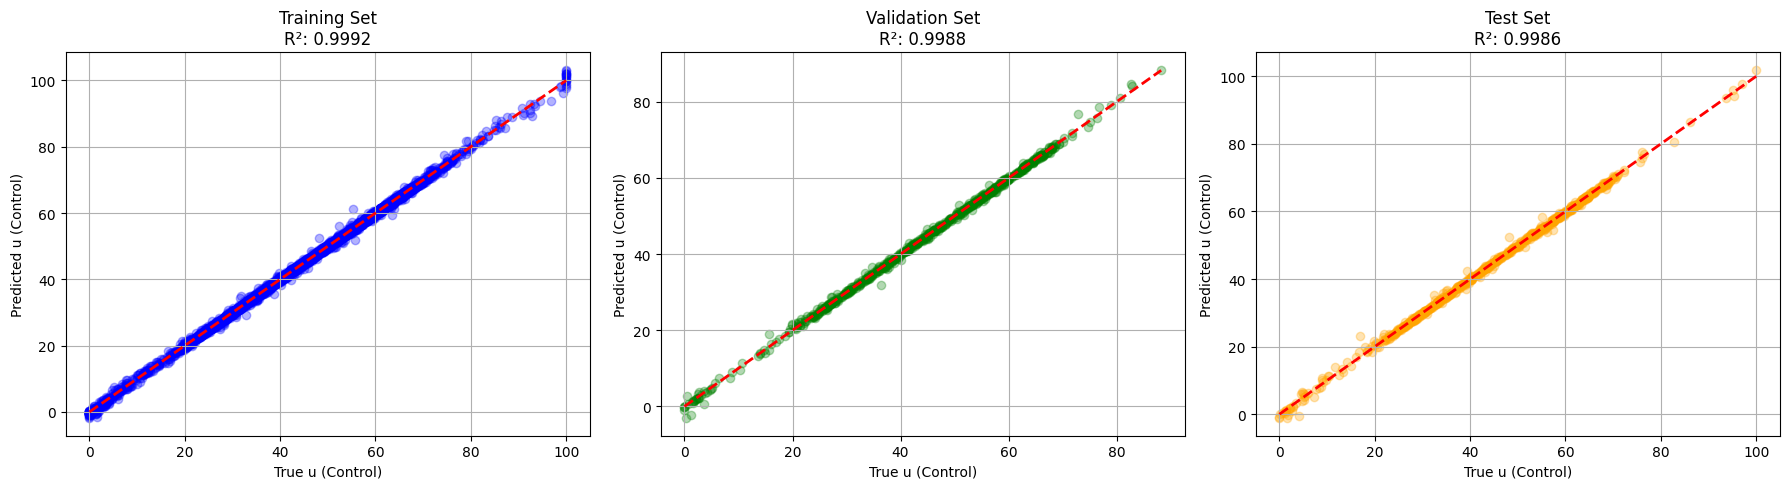

In [10]:
# 9. ANN Creation and Training
# Define the MLP (increased capacity for nx+N=35 inputs)
class MPCApproximator(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(MPCApproximator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )
        
    def forward(self, x):
        return self.net(x)

# Normalize inputs ONLY using StandardScaler to match robust template
scaler = StandardScaler()
P_scaled = scaler.fit_transform(P_data)

# Split data into train, validation, and test sets to monitor overfitting and evaluate generalization
X_train_val, X_test, y_train_val, y_test = train_test_split(P_scaled, U_data, test_size=0.1, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1111, random_state=42)

tensor_X_train = torch.tensor(X_train, dtype=torch.float32)
tensor_y_train = torch.tensor(y_train, dtype=torch.float32)
tensor_X_val = torch.tensor(X_val, dtype=torch.float32)
tensor_y_val = torch.tensor(y_val, dtype=torch.float32)
tensor_X_test = torch.tensor(X_test, dtype=torch.float32)
tensor_y_test = torch.tensor(y_test, dtype=torch.float32)

train_dataset = TensorDataset(tensor_X_train, tensor_y_train)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# model = MPCApproximator(input_dim=nx + N, output_dim=1)
model = MPCApproximator(input_dim=nx + N, output_dim=1)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)  # NEW: reduced for training stability

epochs = 150  # NEW: increased epochs to allow model to converge fully
train_loss_history = []
val_loss_history = []

print("Training ANN...")
for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_loss_history.append(epoch_loss / len(train_loader))
    
    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(tensor_X_val)
        val_loss = criterion(val_outputs, tensor_y_val).item()
    val_loss_history.append(val_loss)
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss_history[-1]:.4f} - Val Loss: {val_loss_history[-1]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(train_loss_history, label='Train Loss')
plt.plot(val_loss_history, label='Val Loss')
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE (Raw Control Input)")
plt.legend()
plt.grid()
plt.show()

# Plot y vs yhat on training, val, and test (side by side)
model.eval()
with torch.no_grad():
    y_train_pred = model(tensor_X_train).numpy()
    y_val_pred = model(tensor_X_val).numpy()
    y_test_pred = model(tensor_X_test).numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Training plot
axes[0].scatter(y_train, y_train_pred, alpha=0.3, color='blue')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_title(f"Training Set\nR²: {r2_score(y_train, y_train_pred):.4f}")
axes[0].set_xlabel("True u (Control)")
axes[0].set_ylabel("Predicted u (Control)")
axes[0].grid(True)

# Validation plot
axes[1].scatter(y_val, y_val_pred, alpha=0.3, color='green')
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
axes[1].set_title(f"Validation Set\nR²: {r2_score(y_val, y_val_pred):.4f}")
axes[1].set_xlabel("True u (Control)")
axes[1].set_ylabel("Predicted u (Control)")
axes[1].grid(True)

# Test plot
axes[2].scatter(y_test, y_test_pred, alpha=0.3, color='orange')
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[2].set_title(f"Test Set\nR²: {r2_score(y_test, y_test_pred):.4f}")
axes[2].set_xlabel("True u (Control)")
axes[2].set_ylabel("Predicted u (Control)")
axes[2].grid(True)

plt.tight_layout()
plt.show()


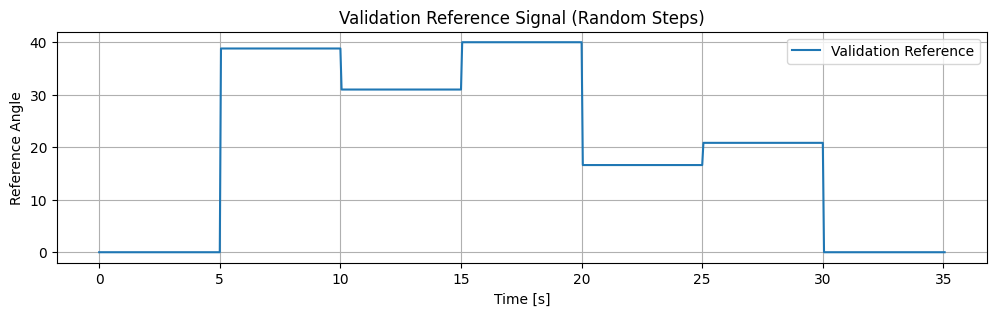

In [12]:
# 10. Validation Test Signal Generation (Sinusoid)
np.random.seed(24)

total_time_val = 60.0  # seconds
tvec_test = np.arange(0, total_time_val, Ts)
x2ref_val = np.zeros_like(tvec_test)

for i, t in enumerate(tvec_test):
    if t < 5.0:
        x2ref_val[i] = 0.0
    else:
        t_osc = t - 5.0
        omega = 2 * np.pi / 15.0
        x2ref_val[i] = 22.5 + 22.5 * np.sin(omega * t_osc - np.pi / 2)

steps_test = len(x2ref_val)

plt.figure(figsize=(12, 3))
plt.plot(tvec_test, x2ref_val, label='Validation Reference')
plt.xlabel('Time [s]')
plt.ylabel('Reference Angle')
plt.title('Validation Reference Signal (Smooth Sinusoid)')
plt.legend()
plt.grid(True)
plt.show()


Simulating Optimal MPC on Test Signal...
Simulating ANN on Test Signal...
MPC Simulation Time: 5.07 s
ANN Simulation Time: 0.23 s
Speedup Factor: 21.69x


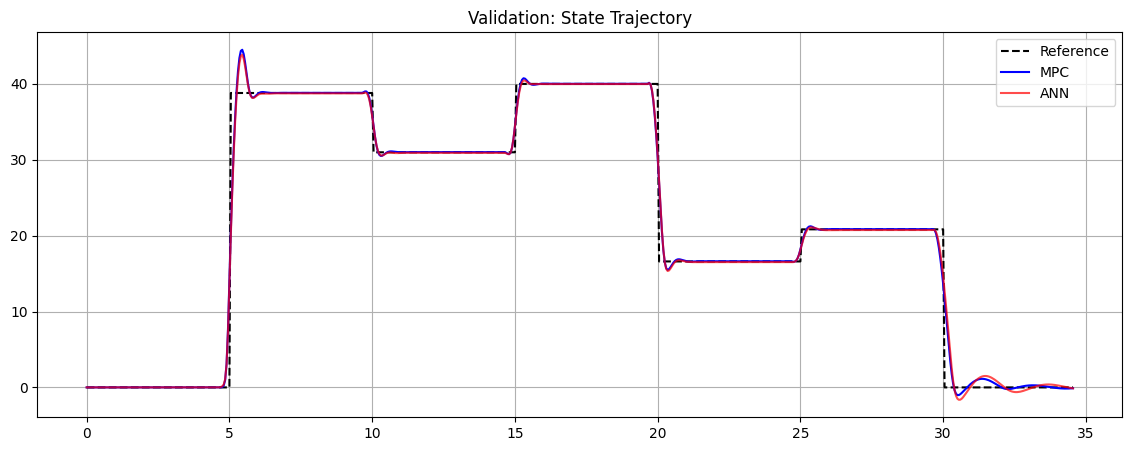

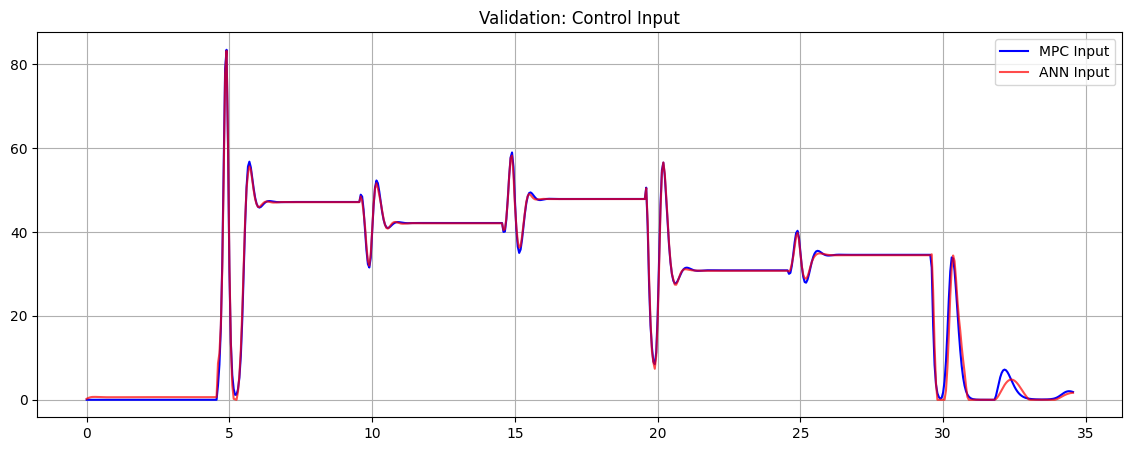

In [13]:
# 11. Validation Simulation (MPC vs ANN)
# Simulate MPC for Validation
xsim_val_mpc = np.zeros((nx, 1))
ysim_val_mpc = []
usim_val_mpc = []
w0_val = np.zeros(w.shape[0])

sim_steps_test = steps_test - N

start_time = time.time()
print("Simulating Optimal MPC on Test Signal...")
for k in range(sim_steps_test):
    ref_window = x2ref_val[k : k + N]
    pval = np.concatenate([xsim_val_mpc[:, -1], ref_window])
    
    sol = solver(x0=w0_val, lbx=lbw, ubx=ubw, lbg=lbg, ubg=ubg, p=pval)
    
    w_opt = sol['x'].full().flatten()
    u_opt = w_opt[nx]
    
    sim_step = F(x0=xsim_val_mpc[:, -1], p=u_opt)
    xk1 = sim_step['xf'].full().flatten()
    yk = sim_step['yk'].full().item()
    
    xsim_val_mpc = np.c_[xsim_val_mpc, xk1]
    usim_val_mpc.append(u_opt)
    ysim_val_mpc.append(yk)
    w0_val = w_opt
mpc_time = time.time() - start_time

# Simulate ANN
xsim_val_ann = np.zeros((nx, 1))
ysim_val_ann = []
usim_val_ann = []

start_time = time.time()
print("Simulating ANN on Test Signal...")
model.eval()
with torch.no_grad():
    for k in range(sim_steps_test):
        ref_window = x2ref_val[k : k + N]
        # pval = np.concatenate([xsim_val_ann[:, -1], ref_window])
        pval = np.concatenate([xsim_val_ann[:, -1], ref_window])
        
        # Normalize input exactly as in training
        pval_scaled = scaler.transform(pval.reshape(1, -1))
        p_tensor = torch.tensor(pval_scaled, dtype=torch.float32)
        
        # Predict (Directly outputs raw control value since we didn't scale Y)
        u_opt = model(p_tensor).item()
        
        # Bound the ANN output to strictly respect limits
        u_opt = np.clip(u_opt, data['u_min'][0], data['u_max'][0])
        
        sim_step = F(x0=xsim_val_ann[:, -1], p=u_opt)
        xk1 = sim_step['xf'].full().flatten()
        yk = sim_step['yk'].full().item()
        
        xsim_val_ann = np.c_[xsim_val_ann, xk1]
        usim_val_ann.append(u_opt)
        ysim_val_ann.append(yk)
ann_time = time.time() - start_time

print(f"MPC Simulation Time: {mpc_time:.2f} s")
print(f"ANN Simulation Time: {ann_time:.2f} s")
print(f"Speedup Factor: {mpc_time/ann_time:.2f}x")

tvec_plot = np.arange(0, sim_steps_test * Ts, Ts)

plt.figure(figsize=(14, 5))
plt.plot(tvec_plot, x2ref_val[:sim_steps_test], 'k--', label='Reference')
plt.plot(tvec_plot, ysim_val_mpc, 'b-', label='MPC')
plt.plot(tvec_plot, ysim_val_ann, 'r-', alpha=0.7, label='ANN')
plt.title('Validation: State Trajectory')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(tvec_plot, usim_val_mpc, 'b-', label='MPC Input')
plt.plot(tvec_plot, usim_val_ann, 'r-', alpha=0.7, label='ANN Input')
plt.title('Validation: Control Input')
plt.legend()
plt.grid()
plt.show()


In [ ]:
import joblib
import torch

torch.save(model.state_dict(), 'ann_model.pth')
joblib.dump(scaler, 'scaler.pkl')
